<a href="https://colab.research.google.com/github/prodigal94/food-safe-bots/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install pyspark

In [12]:
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
# Initialize Spark with optimizations for large data
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("BDA_Project") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import gdown
import os

# Your Google Drive folder link
gdrive_url = 'https://drive.google.com/drive/folders/1kwC9jjZIo6gkLsVS-EAoMkCpPaZV-vV-?usp=drive_link'

# Since it's a folder, we use download_folder
# This will download the contents into the 'Trade_Data_Folder' directory
output_dir = 'Trade_Data_Folder'
gdown.download_folder(gdrive_url, output=output_dir, quiet=False)

# Find the CSV file inside the downloaded folder to set the file_path
csv_files = [f for f in os.listdir(output_dir) if f.endswith('.csv')]
if csv_files:
    output = os.path.join(output_dir, csv_files[0])
    file_path = f'file://{os.path.abspath(output)}'
    print(f'File downloaded to: {output}')
else:
    print('No CSV file found in the downloaded folder.')

Retrieving folder contents


Processing file 1Y8Ooql1IKUldnWyK1hyh-m82hHURd13u Trade_CropsLivestock_E_All_Data_(Normalized).csv
Processing file 1ghGzQRCxuRu1nj90QJWQlscgInhI4lc8 Trade_CropsLivestock_E_AreaCodes.csv
Processing file 1dJr7q5o4bz37ATZGXcOCP0bzigQ5BEyD Trade_CropsLivestock_E_Elements.csv
Processing file 18dqqV_oZDl1zEzXKoyOVqFmH3ih0DSRo Trade_CropsLivestock_E_Flags.csv
Processing file 1DN12ySYIFPwWKBRkYfMWOmeHWTpcnbos Trade_CropsLivestock_E_ItemCodes.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1Y8Ooql1IKUldnWyK1hyh-m82hHURd13u
From (redirected): https://drive.google.com/uc?id=1Y8Ooql1IKUldnWyK1hyh-m82hHURd13u&confirm=t&uuid=fdf2be62-cd51-4578-84a2-7425608d0ded
To: /content/Trade_Data_Folder/Trade_CropsLivestock_E_All_Data_(Normalized).csv
100%|██████████| 2.45G/2.45G [00:30<00:00, 79.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ghGzQRCxuRu1nj90QJWQlscgInhI4lc8
To: /content/Trade_Data_Folder/Trade_CropsLivestock_E_AreaCodes.csv
100%|██████████| 7.58k/7.58k [00:00<00:00, 15.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1dJr7q5o4bz37ATZGXcOCP0bzigQ5BEyD
To: /content/Trade_Data_Folder/Trade_CropsLivestock_E_Elements.csv
100%|██████████| 236/236 [00:00<00:00, 796kB/s]
Downloading...
From: https://drive.google.com/uc?id=18dqqV_oZDl1zEzXKoyOVqFmH3ih0DSRo
To: /content/Trade_Data_Folder/Trad

File downloaded to: Trade_Data_Folder/Trade_CropsLivestock_E_Flags.csv



Download completed


In [16]:
# Re-attempt reading the file locally
df = spark.read.csv(output, header=True, inferSchema=True)
display(df.limit(5).toPandas())

,Flag,Description
0,A,Official figure
1,E,Estimated value
2,I,Value imputed by a receiving agency
3,X,Figure from external organization


In [18]:
# Update to use the file downloaded via gdown
# 'output' was defined in the gdown cell (31c82f7e)
df = spark.read.csv(output, header=True, inferSchema=True)
print(f"Successfully loaded: {output}")

Successfully loaded: Trade_Data_Folder/Trade_CropsLivestock_E_Flags.csv


In [19]:
import os
# List files in the CSV directory to verify the filename
csv_dir = '/content/drive/MyDrive/CSV/'
if os.path.exists(csv_dir):
    print("Files in directory:")
    for f in os.listdir(csv_dir):
        print(f)
else:
    print(f"Directory not found: {csv_dir}")

Directory not found: /content/drive/MyDrive/CSV/


In [20]:
df_before = df  # This is just a reference, not a copy

In [21]:
# Cache the dataframe to avoid recomputation
df.cache()

total_records = df.count()
print(f"Total records: {total_records:,}")
print(f"Total columns: {len(df.columns)}")

Total records: 4
Total columns: 2


In [22]:
print("\n--- Dataset Overview (BEFORE) ---")
# Check rows with missing values BEFORE
print("\n--- Rows with Missing Values (BEFORE) ---")

# Count rows that have ANY missing value
rows_with_missing = df.filter(
    F.greatest(*[F.when(F.col(c).isNull(), 1).otherwise(0) for c in df.columns]) == 1
).count()

rows_complete = total_records - rows_with_missing
print(f"  Complete rows (no missing): {rows_complete:,} ({rows_complete/total_records*100:.2f}%)")
print(f"  Rows with missing values: {rows_with_missing:,} ({rows_with_missing/total_records*100:.2f}%)")


--- Dataset Overview (BEFORE) ---

--- Rows with Missing Values (BEFORE) ---
  Complete rows (no missing): 4 (100.00%)
  Rows with missing values: 0 (0.00%)


In [28]:
# Explicitly load the main data file from the downloaded folder
main_data_path = 'Trade_Data_Folder/Trade_CropsLivestock_E_All_Data_(Normalized).csv'
df = spark.read.csv(main_data_path, header=True, inferSchema=True)

# Now get year range
min_year = df.select(F.min('Year')).collect()[0][0]
max_year = df.select(F.max('Year')).collect()[0][0]
print(f"Year range: {min_year} - {max_year}")

Year range: 1961 - 2024


In [29]:
# Check duplicates BEFORE
print("\n--- Duplicate Records (BEFORE) ---")
duplicates_before = total_records - df.distinct().count()
print(f"Duplicate rows: {duplicates_before:,}")


--- Duplicate Records (BEFORE) ---
Duplicate rows: -17,270,627


In [ ]:
# EDA 1: TOTAL TRADE ITEMS (ALL PRODUCTS TOGETHER - RECORD COUNTS ONLY)
print("\n" + "=" * 60)
print("EDA 1: COUNT FOR EACH TRADE ITEM (ALL PRODUCTS)")
print("=" * 60)

# Show total distinct trade items
distinct_items = df_before.select("Item").distinct().count()
print(f"\n TOTAL DISTINCT TRADE ITEMS: {distinct_items:,}")
print(f" TOTAL RECORDS: {df_before.count():,}")

# Count for each trade item (ALL items together) - NO VALUE
item_counts_before = df_before.groupBy("Item").agg(
    F.count("*").alias("Record_Count")
).orderBy(F.desc("Record_Count"))

print("\n TOP 20 ITEMS BY RECORD COUNT (ALL PRODUCTS TOGETHER):")
item_counts_before.show(20, truncate=False)

# Collect for visualization (top 15 for better view)
item_top_list = item_counts_before.limit(15).collect()
items_top = [row.Item for row in item_top_list]
counts_top = [row.Record_Count for row in item_top_list]

# VISUALIZATION
plt.figure(figsize=(12, 8))

plt.barh(items_top, counts_top, color='steelblue', edgecolor='black')
plt.title('Top 15 Trade Items by Record Count\n(All Crops & Livestock Products Together)',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Records', fontsize=12)
plt.ylabel('Trade Item', fontsize=12)

# Add value labels
for i, v in enumerate(counts_top):
    plt.text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Simple summary
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"Total Distinct Items: {distinct_items:,}")
print(f"Total Records: {df_before.count():,}")
print(f"Average Records per Item: {df_before.count() / distinct_items:,.1f}")

# Most and least frequent items
print(f"\nMost frequent item: {item_counts_before.first()['Item']} ({item_counts_before.first()['Record_Count']:,} records)")
least_frequent = item_counts_before.orderBy(F.asc("Record_Count")).filter(F.col("Record_Count") > 0).first()
print(f"Least frequent item: {least_frequent['Item']} ({least_frequent['Record_Count']:,} records)")

In [ ]:
# DATA CLEANING
print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)

df = df.dropDuplicates()

df = df.na.fill("Unknown", subset=["Area", "Item", "Element", "Unit", "Flag", "Note"])

df = df.na.fill(0, subset=["Value"])

df = df.dropna(subset=["Year"])

df = df.select("Area", "Item", "Element", "Year", "Unit", "Value", "Flag", "Note")

df = df.orderBy("Area", "Item", "Year")

df_after = df

print("Rows after cleaning:", df_after.count())
print("Columns after cleaning:", len(df_after.columns))
df_after.show(5, truncate=False)


In [ ]:
print("\n--- Dataset Overview (AFTER) ---")
print("\n--- Rows with Missing Values (AFTER) ---")

total_records_after = df_after.count()

rows_with_missing_after = df_after.filter(
    F.greatest(*[F.when(F.col(c).isNull(), 1).otherwise(0) for c in df_after.columns]) == 1
).count()

rows_complete_after = total_records_after - rows_with_missing_after
print(f"  Complete rows (no missing): {rows_complete_after:,} ({rows_complete_after/total_records_after*100:.2f}%)")
print(f"  Rows with missing values: {rows_with_missing_after:,} ({rows_with_missing_after/total_records_after*100:.2f}%)")


In [ ]:
min_year_after = df_after.select(F.min('Year')).collect()[0][0]
max_year_after = df_after.select(F.max('Year')).collect()[0][0]
print(f"Year range after cleaning: {min_year_after} - {max_year_after}")


In [ ]:
# EDA 2: TOTAL TRADE ITEMS AFTER CLEANING
print("\n" + "=" * 60)
print("EDA 2: COUNT FOR EACH TRADE ITEM (AFTER CLEANING)")
print("=" * 60)

distinct_items_after = df_after.select("Item").distinct().count()
print(f"\nTOTAL DISTINCT TRADE ITEMS: {distinct_items_after:,}")
print(f"TOTAL RECORDS: {df_after.count():,}")

item_counts_after = df_after.groupBy("Item").agg(
    F.count("*").alias("Record_Count")
).orderBy(F.desc("Record_Count"))

print("\nTOP 20 ITEMS BY RECORD COUNT:")
item_counts_after.show(20, truncate=False)

item_top_list_after = item_counts_after.limit(15).collect()
items_top_after = [row.Item for row in item_top_list_after]
counts_top_after = [row.Record_Count for row in item_top_list_after]

plt.figure(figsize=(12, 8))
plt.barh(items_top_after, counts_top_after, color='darkgreen', edgecolor='black')
plt.title('Top 15 Trade Items by Record Count\n(After Cleaning)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Records', fontsize=12)
plt.ylabel('Trade Item', fontsize=12)

for i, v in enumerate(counts_top_after):
    plt.text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


EDA 3: Trade Balance by Country (Net Exporters vs. Importers) In this section, we calculate the Net Trade Balance: Export Value - Import Value.
A positive balance indicates a Net Exporter.
A negative balance indicates a Net Importer.

In [40]:
from pyspark.sql import functions as F

# Ensure we are using the cleaned dataframe
df_after = df.dropDuplicates().dropna(subset=['Year'])

# 1. Filter for the latest year and 'Value' elements in 1000 USD
latest_year = df_after.select(F.max('Year')).collect()[0][0]
trade_val_df = df_after.filter(
    (F.col('Year') == latest_year) &
    (F.col('Unit') == '1000 USD') &
    (F.col('Element').isin(['Import value', 'Export value']))
)

# 2. Aggregate by Area and Element to get total values per country
country_trade = trade_val_df.groupBy("Area", "Element").agg(F.sum("Value").alias("Total_Value"))

# 3. Pivot the data to have Import and Export values as columns
pivoted_trade = country_trade.groupBy("Area").pivot("Element").sum("Total_Value").fillna(0)

# 4. Calculate Net Trade Balance (Export - Import)
# Note: column names from pivot match the values in the 'Element' column
trade_balance = pivoted_trade.withColumn(
    "Net_Balance_Billion_USD",
    (F.col("`Export value`") - F.col("`Import value`")) / 1000000
).orderBy(F.desc("Net_Balance_Billion_USD"))

# Display top exporters and importers
print(f"--- Trade Balance Summary for {latest_year} (in Billion USD) ---")
trade_balance.select("Area", "Net_Balance_Billion_USD").show(10)

--- Trade Balance Summary for 2024 (in Billion USD) ---
+--------------------+-----------------------+
|                Area|Net_Balance_Billion_USD|
+--------------------+-----------------------+
|South America (ex...|     1035.5840300099994|
|       South America|          1016.58594532|
|              Brazil|      681.4753568800002|
| European Union (27)|      636.1096015200004|
|European Union (2...|      588.2675594300003|
|      Western Europe|     509.87882334999847|
|Western Europe (e...|     480.76921753999994|
|     China, mainland|      347.1472659700007|
|Netherlands (King...|           328.73857229|
|Australia and New...|      325.9361348700002|
+--------------------+-----------------------+
only showing top 10 rows


In [39]:
# Diagnostic: Inspect available categories in the data
print("Distinct Elements:")
df.select("Element").distinct().show(truncate=False)

print("\nDistinct Units:")
df.select("Unit").distinct().show(truncate=False)

print(f"\nSample of data for the latest year ({latest_year}):")
df.filter(F.col("Year") == latest_year).select("Element", "Unit", "Value").limit(10).show()

Distinct Elements:
+---------------+
|Element        |
+---------------+
|Import quantity|
|Export quantity|
|Export value   |
|Import value   |
+---------------+


Distinct Units:
+--------+
|Unit    |
+--------+
|No      |
|1000 USD|
|1000 An |
|t       |
|An      |
+--------+


Sample of data for the latest year (2024):
+---------------+--------+------+
|        Element|    Unit| Value|
+---------------+--------+------+
|Import quantity|       t|  0.03|
|Import quantity|       t| 14.78|
|   Import value|1000 USD|   0.0|
|Import quantity|       t|  2.86|
|Import quantity|       t|  1.23|
|Import quantity|       t|  0.76|
|   Import value|1000 USD|  26.0|
|Import quantity|       t|303.86|
|   Import value|1000 USD|  27.0|
|Import quantity|       t|  9.82|
+---------------+--------+------+



/tmp/ipykernel_23198/1328779043.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_exporters, x='Net_Balance_Billion_USD', y='Area', ax=ax1, palette='Greens_r')
/tmp/ipykernel_23198/1328779043.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_importers, x='Net_Balance_Billion_USD', y='Area', ax=ax2, palette='Reds')


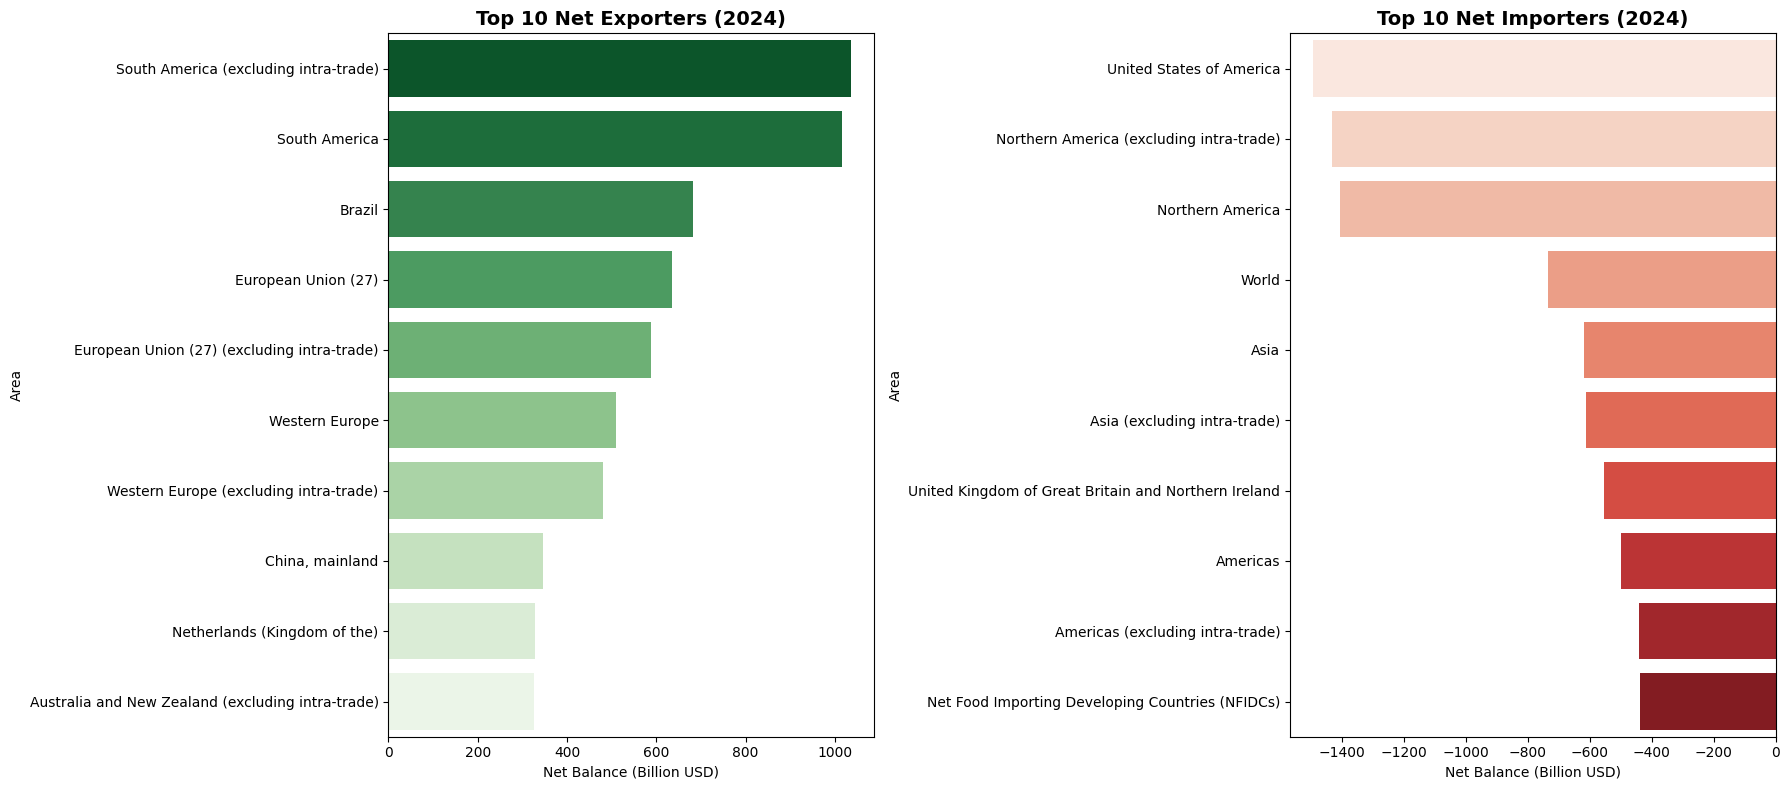

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect data for visualization
# We check if trade_balance exists to provide a better error message if needed
if 'trade_balance' in globals():
    top_exporters = trade_balance.limit(10).toPandas()
    top_importers = trade_balance.orderBy("Net_Balance_Billion_USD").limit(10).toPandas()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # Plot Top 10 Net Exporters
    sns.barplot(data=top_exporters, x='Net_Balance_Billion_USD', y='Area', ax=ax1, palette='Greens_r')
    ax1.set_title(f'Top 10 Net Exporters ({latest_year})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Net Balance (Billion USD)')

    # Plot Top 10 Net Importers
    sns.barplot(data=top_importers, x='Net_Balance_Billion_USD', y='Area', ax=ax2, palette='Reds')
    ax2.set_title(f'Top 10 Net Importers ({latest_year})', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Net Balance (Billion USD)')

    plt.tight_layout()
    plt.show()
else:
    print("Error: 'trade_balance' is not defined. Please run the calculation cell (JgSJQZ8OGllY) first.")